In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df =pd.read_csv("/content/test_sample (1).csv")

In [ ]:
df.head()

,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type
0,1412188,49.0,Female,18460.0,Single,NaN,High School,Unemployed,39.592805,Rural,Premium,2.0,18.0,426.0,7.0,2021-01-23 15:21:39.121169,Good,No,Rarely,House
1,1499036,25.0,Female,3532.0,Single,1.0,Master's,Employed,7.693660,Suburban,Premium,2.0,19.0,464.0,5.0,2020-12-28 15:21:39.228521,Good,No,Daily,Condo
2,1675978,40.0,Female,75212.0,Divorced,3.0,Master's,Unemployed,43.763111,Urban,Premium,3.0,0.0,NaN,2.0,2024-03-04 15:21:39.126661,Good,No,Monthly,House
3,1788988,28.0,Male,21881.0,Married,1.0,Bachelor's,Self-Employed,20.814495,Suburban,Premium,NaN,16.0,643.0,4.0,2021-03-21 15:21:39.285112,Poor,No,Rarely,Apartment
4,1338859,49.0,Female,14192.0,Single,4.0,PhD,NaN,7.532147,Urban,Premium,1.0,1.0,413.0,6.0,2021-03-07 15:21:39.217387,Good,Yes,Monthly,House


In [ ]:
df.isnull().sum()

,0
id,0
Age,1533
Gender,0
Annual Income,3732
Marital Status,1591
Number of Dependents,9085
Education Level,0
Occupation,29954
Health Score,6233
Location,0


<Axes: >

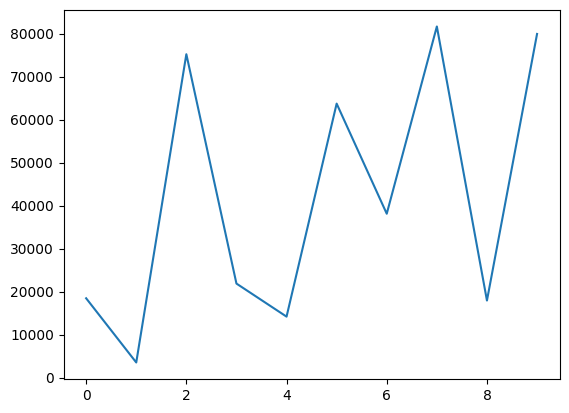

In [ ]:
x=df['Annual Income'][0:10]
x.plot()

<Axes: ylabel='Annual Income'>

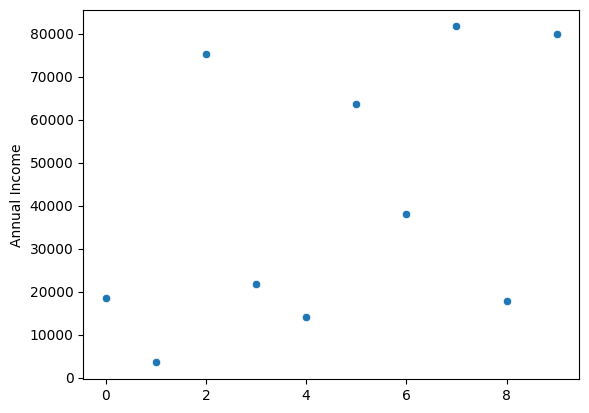

In [ ]:
sns.scatterplot(x)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , classification_report
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()
df['Education Level']=le.fit_transform(df['Education Level'])
df['Annual Income']=le.fit_transform(df['Annual Income'])
df

,id,Age,Gender,Annual Income,Marital Status,Number of Dependents,Education Level,Occupation,Health Score,Location,Policy Type,Previous Claims,Vehicle Age,Credit Score,Insurance Duration,Policy Start Date,Customer Feedback,Smoking Status,Exercise Frequency,Property Type
0,1412188,49.0,Female,9121,Single,NaN,1,Unemployed,39.592805,Rural,Premium,2.0,18.0,426.0,7.0,2021-01-23 15:21:39.121169,Good,No,Rarely,House
1,1499036,25.0,Female,2110,Single,1.0,2,Employed,7.693660,Suburban,Premium,2.0,19.0,464.0,5.0,2020-12-28 15:21:39.228521,Good,No,Daily,Condo
2,1675978,40.0,Female,25454,Divorced,3.0,2,Unemployed,43.763111,Urban,Premium,3.0,0.0,NaN,2.0,2024-03-04 15:21:39.126661,Good,No,Monthly,House
3,1788988,28.0,Male,10437,Married,1.0,0,Self-Employed,20.814495,Suburban,Premium,NaN,16.0,643.0,4.0,2021-03-21 15:21:39.285112,Poor,No,Rarely,Apartment
4,1338859,49.0,Female,7315,Single,4.0,3,NaN,7.532147,Urban,Premium,1.0,1.0,413.0,6.0,2021-03-07 15:21:39.217387,Good,Yes,Monthly,House
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1271649,19.0,Male,17635,Married,2.0,1,Employed,11.954773,Rural,Comprehensive,NaN,13.0,796.0,5.0,2022-11-11 15:21:39.134960,Good,No,Daily,Condo
99996,1896385,39.0,Male,1738,Divorced,2.0,1,Self-Employed,NaN,Rural,Basic,NaN,18.0,697.0,8.0,2020-12-12 15:21:39.237118,Good,No,Weekly,Apartment
99997,1404821,38.0,Female,33773,Single,0.0,0,Employed,5.710345,Urban,Comprehensive,1.0,13.0,NaN,6.0,2022-09-23 15:21:39.132191,Average,No,Rarely,House
99998,1687855,51.0,Male,24564,Divorced,0.0,2,Employed,29.569359,Rural,Premium,1.0,14.0,379.0,1.0,2022-11-12 15:21:39.256696,Average,Yes,Monthly,Condo


In [ ]:
df = df.drop("id", axis=1)

In [ ]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col].astype(str))

In [ ]:
y = df["Policy Type"]
X = df.drop("Policy Type", axis=1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=42
)


In [ ]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.3332
              precision    recall  f1-score   support

           0       0.33      0.06      0.11      6640
           1       0.33      0.91      0.49      6626
           2       0.35      0.03      0.05      6734

    accuracy                           0.33     20000
   macro avg       0.34      0.34      0.22     20000
weighted avg       0.34      0.33      0.21     20000

